<a href="https://colab.research.google.com/github/Deed-buggy/Dyslexia_Dashboard_2026/blob/main/dyslexia_detection_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, gc, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns
import kagglehub, cv2
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score, roc_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold

tf.keras.backend.clear_session()
gc.collect()
tf.keras.mixed_precision.set_global_policy('mixed_float16')
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

In [ ]:
path = kagglehub.dataset_download("prthmproxy/dyslexia-dataset")
train_path = os.path.join(path, "Train")

image_paths, labels = [], []
class_names = sorted(os.listdir(train_path))
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(train_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(class_to_idx[class_name])


100%|██████████| 464M/464M [00:12<00:00, 38.4MB/s]

Extracting files...


In [ ]:

X_train_val, X_test, y_train_val, y_test = train_test_split(
    np.array(image_paths), np.array(labels), test_size=0.2, random_state=42, stratify=labels
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

def preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, tf.one_hot(label, len(class_names))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(preprocess_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(preprocess_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(preprocess_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print(f" Data Ready. Classes: {class_names}")
print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

 Data Ready. Classes: ['Corrected', 'Normal', 'Reversal']
Train samples: 90989
Validation samples: 30330
Test samples: 30330


In [ ]:
def build_model():
    base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(len(class_names), activation='softmax', dtype='float32')(x) # float32 for stability

    return models.Model(inputs, outputs), base

model, base_model = build_model()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.compile(optimizer=optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
print(" Phase 1: Training...")
history1 = model.fit(train_ds, validation_data=val_ds, epochs=5)

 Phase 1: Training...
Epoch 1/5
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 245s 128ms/step - accuracy: 0.8142 - loss: 0.9277 - val_accuracy: 0.8507 - val_loss: 0.4869
Epoch 2/5
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - accuracy: 0.8280 - loss: 0.5415 - val_accuracy: 0.8720 - val_loss: 0.4447
Epoch 3/5
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - accuracy: 0.8352 - loss: 0.5123 - val_accuracy: 0.8717 - val_loss: 0.4237
Epoch 4/5
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 93s 59ms/step - accuracy: 0.8412 - loss: 0.4881 - val_accuracy: 0.8835 - val_loss: 0.3873
Epoch 5/5
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 130s 51ms/step - accuracy: 0.8448 - loss: 0.4720 - val_accuracy: 0.8920 - val_loss: 0.3664


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-30]: layer.trainable = False

model.compile(optimizer=optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Phase 2: Fine-Tuning...")
model.fit(train_ds, validation_data=val_ds, epochs=10, initial_epoch=history1.epoch[-1], callbacks=[early_stop])

Phase 2: Fine-Tuning...
Epoch 5/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 222s 115ms/step - accuracy: 0.7960 - loss: 0.5851 - val_accuracy: 0.8882 - val_loss: 0.3707
Epoch 6/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.8698 - loss: 0.4122 - val_accuracy: 0.9200 - val_loss: 0.2981
Epoch 7/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 81s 57ms/step - accuracy: 0.8988 - loss: 0.3458 - val_accuracy: 0.9363 - val_loss: 0.2530
Epoch 8/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 82s 57ms/step - accuracy: 0.9157 - loss: 0.3033 - val_accuracy: 0.9464 - val_loss: 0.2193
Epoch 9/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.9287 - loss: 0.2692 - val_accuracy: 0.9549 - val_loss: 0.1949
Epoch 10/10
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9380 - loss: 0.2412 - val_accuracy: 0.9605 - val_loss: 0.1742



--- Corrected Classification Report ---
              precision    recall  f1-score   support

   Corrected       0.98      0.97      0.98     13107
      Normal       0.95      0.96      0.95      7867
    Reversal       0.94      0.95      0.95      9356

    accuracy                           0.96     30330
   macro avg       0.96      0.96      0.96     30330
weighted avg       0.96      0.96      0.96     30330

Final Cohen's Kappa: 0.9395


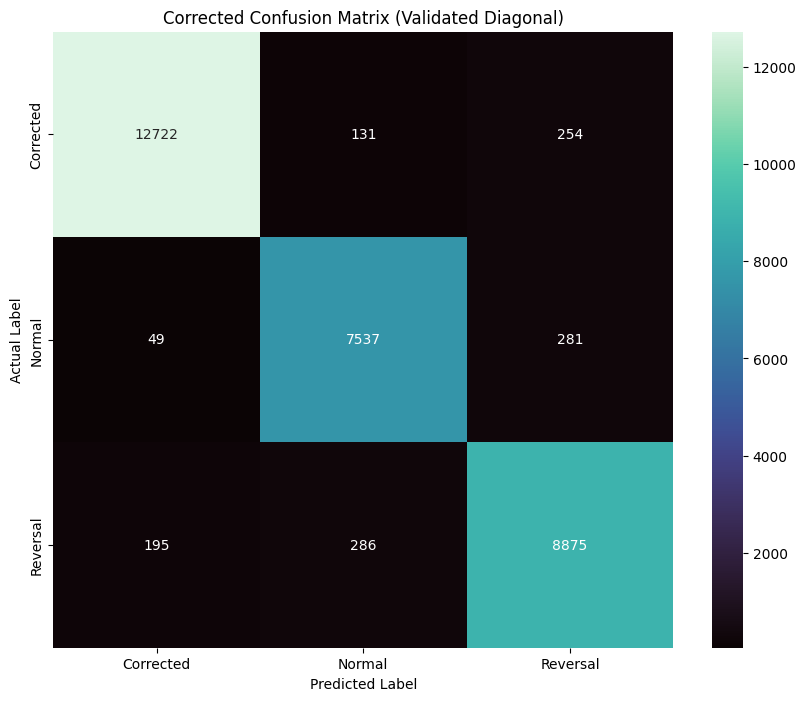

In [ ]:
y_true = []
y_pred = []
for images, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))

print("\n--- Corrected Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))
kappa = cohen_kappa_score(y_true, y_pred)
print(f"Final Cohen's Kappa: {kappa:.4f}")
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='mako',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Corrected Confusion Matrix (Validated Diagonal)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

 Generating X-AI Visuals (Stable Graph)...


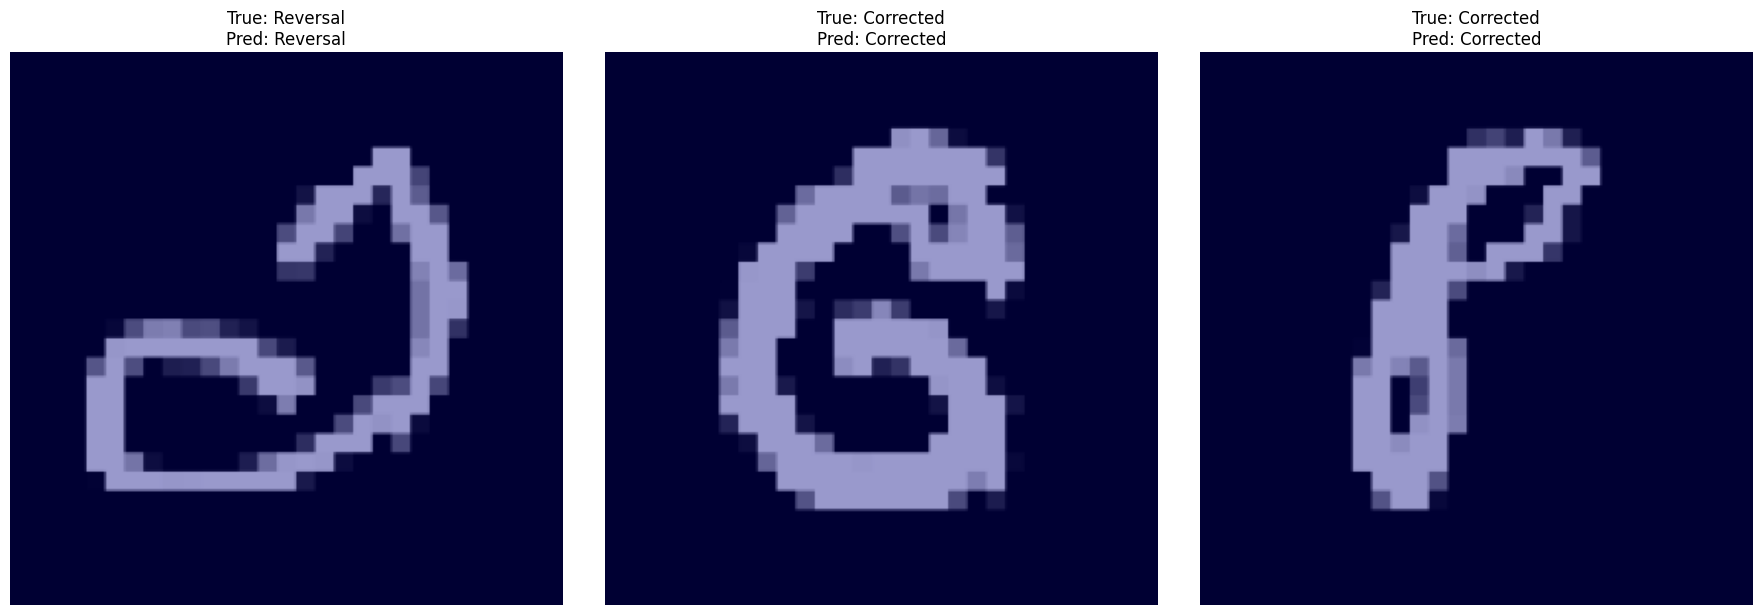

In [ ]:
import cv2

def get_stable_gradcam(img_tensor, model):
    try:
        base = model.get_layer('efficientnetb0')
    except:
        base = [l for l in model.layers if 'efficientnet' in l.name][0]

    base_idx = [i for i, l in enumerate(model.layers) if l == base][0]
    head_layers = model.layers[base_idx + 1:]
    last_conv_layer = base.get_layer("top_conv")
    feature_model = tf.keras.Model(base.input, last_conv_layer.output)

    with tf.GradientTape() as tape:
        inputs = tf.cast(img_tensor, tf.float32)
        preprocessed_input = tf.keras.applications.efficientnet.preprocess_input(inputs)

        conv_outputs = feature_model(preprocessed_input)
        tape.watch(conv_outputs)
        x = base(preprocessed_input)
        for layer in head_layers:
            x = layer(x)

        preds = x
        top_class_idx = tf.argmax(preds[0])
        loss = preds[:, top_class_idx]
    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        return np.zeros((7, 7))
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = conv_outputs[0] @ weights[..., tf.newaxis]
    cam = tf.maximum(cam, 0) / (tf.math.reduce_max(cam) + 1e-10)
    return cam.numpy()
print(" Generating X-AI Visuals (Stable Graph)...")

for images, labels in val_ds.take(1):
    plt.figure(figsize=(18, 6))
    for i in range(3):
        img_in = tf.expand_dims(images[i], axis=0)

        try:
            heatmap = get_stable_gradcam(img_in, model)
            res = model.predict(img_in, verbose=0)
            p_idx, t_idx = np.argmax(res[0]), np.argmax(labels[i])
            img_np = images[i].numpy()
            img_std = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-10)
            img_uint8 = np.uint8(255 * img_std)

            heatmap_res = cv2.resize(heatmap, (224, 224))
            heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
            display = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)

            plt.subplot(1, 3, i+1)
            plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
            plt.title(f"True: {class_names[t_idx]}\nPred: {class_names[p_idx]}")
            plt.axis('off')

        except Exception as e:
            print(f"Image {i} failed: {e}")

    plt.tight_layout()
    plt.show()
    break


Epoch 1/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 215s 124ms/step - accuracy: 0.6757 - loss: 4.8064 - val_accuracy: 0.8144 - val_loss: 4.2167
Epoch 2/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 86s 61ms/step - accuracy: 0.7713 - loss: 4.0496 - val_accuracy: 0.8433 - val_loss: 3.6378
Epoch 3/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 74s 52ms/step - accuracy: 0.7983 - loss: 3.4931 - val_accuracy: 0.8611 - val_loss: 3.1363
Epoch 4/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.8181 - loss: 3.0113 - val_accuracy: 0.8711 - val_loss: 2.7058
Epoch 5/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.8301 - loss: 2.6050 - val_accuracy: 0.8797 - val_loss: 2.3393
Epoch 6/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 79s 52ms/step - accuracy: 0.8412 - loss: 2.2588 - val_accuracy: 0.8853 - val_loss: 2.0296
Epoch 7/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.8461 - loss: 1.9716 - val_accuracy: 0.8908 - val_loss: 1.7690
Epoch 8/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.8556

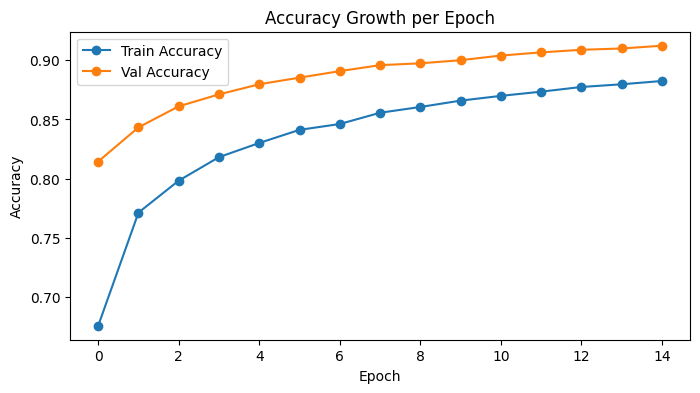

In [ ]:
best_lr = 1e-5
stop_early = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
model, base_model = build_model()
model.compile(optimizer=optimizers.Adam(learning_rate=best_lr), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[stop_early])
val_acc_list = history.history['val_accuracy']
best_epoch = np.argmax(val_acc_list) + 1
train_acc = history.history['accuracy'][best_epoch-1]
val_acc = val_acc_list[best_epoch-1]
first_acc = history.history['accuracy'][0]
perc_inc = ((train_acc - first_acc) / (first_acc + 1e-10)) * 100

print("\n" + "="*40)
print("FINAL MODEL PERFORMANCE REPORT")
print("="*40)
print(f"Best Learning Rate:    {best_lr}")
print(f"Best Training Epoch:   {best_epoch}")
print(f"Final Training Acc:    {train_acc*100:.2f}%")
print(f"Final Validation Acc:  {val_acc*100:.2f}%")
print(f"Accuracy % Increase:   {perc_inc:.2f}%")
print("="*40)
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Accuracy Growth per Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.show()

In [ ]:
y_true, y_pred = [], []
for images, labels in val_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(model.predict(images, verbose=0), axis=1))

cm = confusion_matrix(y_true, y_pred)

print("\nCLASS-WISE ERROR ANALYSIS")
print("-" * 35)
for i, name in enumerate(class_names):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fp + fn)
    print(f"Class: {name:<12} | TN: {tn:<5} | FN: {fn:<5}")
print("-" * 35)


CLASS-WISE ERROR ANALYSIS
-----------------------------------
Class: Corrected    | TN: 16547 | FN: 613  
Class: Normal       | TN: 21313 | FN: 522  
Class: Reversal     | TN: 20131 | FN: 1534 
-----------------------------------


In [ ]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, confusion_matrix, classification_report, cohen_kappa_score
from sklearn.preprocessing import label_binarize

y_true_final = []
y_pred_proba_final = []

for images, labels in val_ds:
    y_true_final.extend(np.argmax(labels.numpy(), axis=1))
    preds_proba = model.predict(images, verbose=0)
    y_pred_proba_final.extend(preds_proba)

y_true_final = np.array(y_true_final)
y_pred_proba_final = np.array(y_pred_proba_final)
y_pred_final = np.argmax(y_pred_proba_final, axis=1)


y_true_binarized = label_binarize(y_true_final, classes=range(len(class_names)))


cm_final = confusion_matrix(y_true_final, y_pred_final)

print("\n--- Final Comprehensive Classification Report ---")
print(classification_report(y_true_final, y_pred_final, target_names=class_names))


print("\nSpecificity per class:")
specificities = {}
for i, name in enumerate(class_names):
    tp = cm_final[i, i]
    fn = np.sum(cm_final[i, :]) - tp
    fp = np.sum(cm_final[:, i]) - tp
    tn = np.sum(cm_final) - (tp + fn + fp)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities[name] = specificity
    print(f"  {name}: {specificity:.4f}")

kp_final = cohen_kappa_score(y_true_final, y_pred_final)
print(f"\nFinal Cohen's Kappa: {kp_final:.4f}")


print("\nAUC-ROC per class:")
aurocs = {}
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_proba_final[:, i])
    roc_auc = auc(fpr, tpr)
    aurocs[class_name] = roc_auc
    print(f"  {class_name}: {roc_auc:.4f}")



--- Final Comprehensive Classification Report ---
              precision    recall  f1-score   support

   Corrected       0.95      0.95      0.95     13107
      Normal       0.86      0.93      0.90      7867
    Reversal       0.90      0.84      0.87      9356

    accuracy                           0.91     30330
   macro avg       0.91      0.91      0.91     30330
weighted avg       0.91      0.91      0.91     30330


Specificity per class:
  Corrected: 0.9608
  Normal: 0.9488
  Reversal: 0.9598

Final Cohen's Kappa: 0.8649

AUC-ROC per class:
  Corrected: 0.9920
  Normal: 0.9869
  Reversal: 0.9747


In [ ]:

if 'model' not in locals() and 'model' not in globals():
    print("Warning: 'model' not found. Re-building and compiling model for test accuracy calculation. This will be an untrained model if training cells were not re-executed.")
    model, base_model = build_model()
    best_lr = 1e-5
    model.compile(optimizer=optimizers.Adam(learning_rate=best_lr), loss='categorical_crossentropy', metrics=['accuracy'])

_, test_acc = model.evaluate(test_ds, verbose=0)

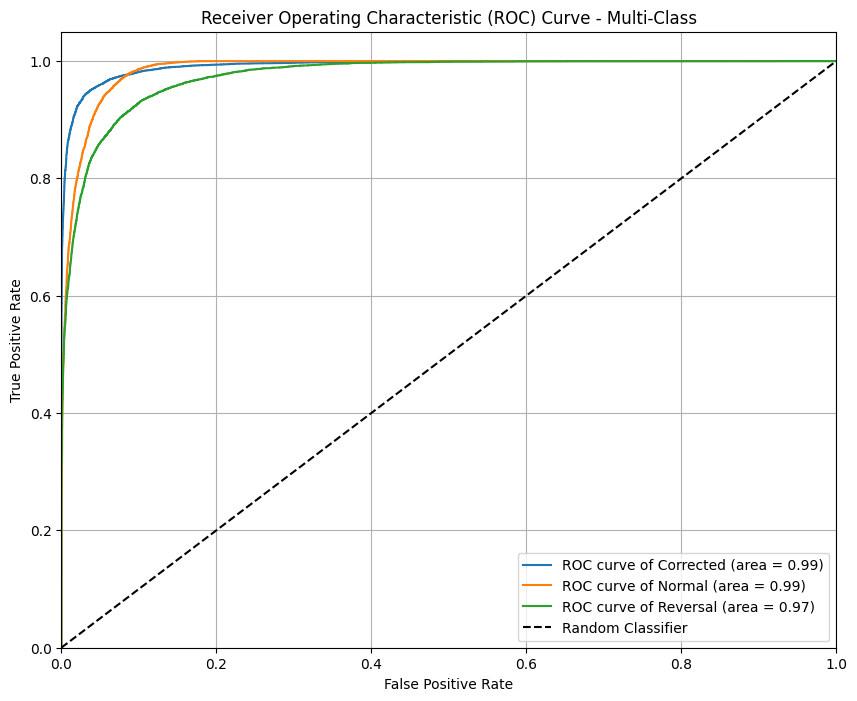

In [ ]:
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_proba_final[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of {class_name} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Multi-Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

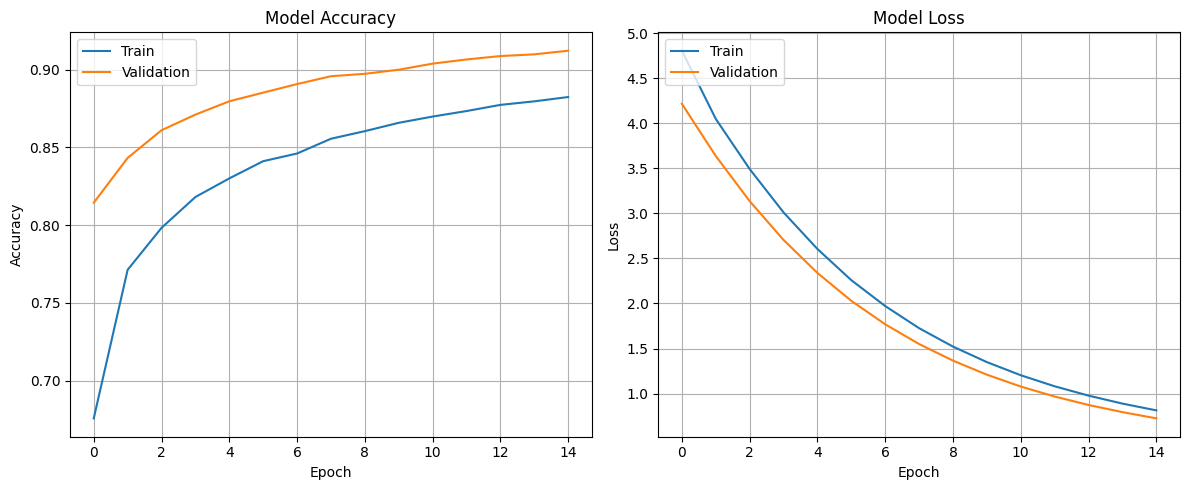

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("PERFORMANCE SUMMARY")
print("="*50)

if 'train_acc' in locals() and 'val_acc' in locals():
    print(f"Training Accuracy   : {train_acc*100:.2f}%")
    print(f"Validation Accuracy : {val_acc*100:.2f}%")
else:
    print("Training Accuracy   : N/A (History not available)")
    print("Validation Accuracy : N/A (History not available)")

if 'test_acc' in locals():
    print(f"Testing Accuracy    : {test_acc*100:.2f}%")
else:
    print("Testing Accuracy    : N/A (Test accuracy not calculated)")

macro_auc = np.mean(list(aurocs.values()))
macro_spec = np.mean(list(specificities.values()))

print(f"Overall Macro AUC   : {macro_auc:.4f}")
print(f"Overall Specificity : {macro_spec:.4f}")
print(f"Cohen's Kappa       : {kp_final:.4f}")
print("="*50)


PERFORMANCE SUMMARY
Training Accuracy   : 88.24%
Validation Accuracy : 91.22%
Testing Accuracy    : 91.24%
Overall Macro AUC   : 0.9845
Overall Specificity : 0.9565
Cohen's Kappa       : 0.8649
